## NETFLIX DATA ANALYSIS
Netflix is known for its work in Data Science, AI, and ML, particularly for building strong recommendation models and algorithms that understand customer behavior and patterns. Suppose you are working in a data-driven job role and have a dataset of more than 9,000 movies. You need to solve the following questions to help the company make informed business decisions accordingly:

	1.	What is the most frequent genre of movies released on Netflix?
	
	2.	Which genre has the highest number of votes?

	3.	What movie has the highest popularity? What’s its genre?

	4.	What movie has the lowest popularity? What’s its genre?

	5.	Which year has the most movies filmed?

In [18]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\tusha\Downloads\mymoviedb.csv", lineterminator='\n')
df.head()




,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [20]:
df['Genre'].head()  

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [21]:
df.duplicated() ## to check wether there are any duplicate rows in the dataset
df.duplicated().sum() ## to count the number of duplicate rows in the dataset

np.int64(0)

In [22]:
df.describe() # to get the summary statistics of the dataset

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


### 📊 **Summary of Data Insights Till Now :**

1. **No Missing or Duplicate Values:**
   All 9,827 records are complete with no null or duplicate entries, ensuring clean and consistent data.

2. **Column Data Types:**
   The dataset contains numeric, textual, and date-related fields. However, the `Release_Date` is currently of object type and needs to be converted to datetime for proper analysis.

3. **Numerical Feature Overview:**

   * **Popularity:**
     Ranges from **13.35** to **5083.95**, with a mean of **40.32**, indicating a few highly popular movies skew the distribution.
   * **Vote Count:**
     Varies from **0** to **31,077**, with a median of **444**, showing many movies have low engagement while a few have high vote volumes.
   * **Vote Average:**
     Spans **0.0** to **10.0**, with a mean of **6.44**, suggesting that most movies are moderately rated.

4. **Text Cleaning Needed:**
   The `Genre` column contains extra spaces that should be stripped for consistent categorization.

5. **Irrelevant Columns:**
   The columns `Overview`, `Original_Language`, and `Poster_Url` can be dropped as they are not essential for our analysis.

---

In [23]:
## TO convert the 'Release_Date' column to datetime format
df['Release_Date'] = pd.to_datetime(df['Release_Date'])  
print(df['Release_Date'].dtype)  # to check the data type of the 'Release_Date' column




datetime64[ns]


In [24]:
df['Release_Date']=pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)  # to check the data type of the 'Release_Date' column
  # to check the first few values of the 'Release_Date' column



datetime64[ns]


In [25]:
df['Release_Date']=df['Release_Date'].dt.year

df['Release_Date'].dtype 

dtype('int32')

In [26]:
df.head()  # to display the first few rows of the dataset after adding the 'Year' column

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


## DROPING THE COLUMNS 

In [29]:
cols = ['Overview', 'Original_Language', 'Poster_Url']

# Save original columns before drop
original_columns = df.columns.tolist()

# Drop only these columns (ignore if any are missing)
df.drop(columns=cols, inplace=True, errors='ignore')

# Save columns after drop
remaining_columns = df.columns.tolist()




In [31]:
df.head()
df.tail()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
9822,1973,Badlands,13.357,896,7.6,"Drama, Crime"
9823,2020,Violent Delights,13.356,8,3.5,Horror
9824,2016,The Offering,13.355,94,5.0,"Mystery, Thriller, Horror"
9825,2021,The United States vs. Billie Holiday,13.354,152,6.7,"Music, Drama, History"
9826,1984,Threads,13.354,186,7.8,"War, Drama, Science Fiction"


## 🧠 Categorizing the Average_Vote Column (Theoretical Explanation)
Categorizing the Average_Vote column involves transforming continuous numerical ratings (typically ranging from 0 to 10) into qualitative categories. This is useful for simplifying analysis, enhancing visualization, or making data more interpretable for non-technical audiences.

In [62]:
import pandas as pd

def categorize_col(df, col, labels):
    # Define bin edges using descriptive statistics
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    
    # Apply pd.cut to categorize values
    df[col] = pd.cut(df[col], edges, labels=labels, duplicates='drop')
    return df

# Define the labels (must be one less than number of edges)
labels = ['not_popular', 'below_avg', 'average', 'popular']

# Apply the function to categorize the column
df = categorize_col(df, 'Vote_Average', labels)

# Show unique categories in the column
print(df['Vote_Average'].unique())




['popular', 'below_avg', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'average' < 'popular']


In [63]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [66]:
df['Vote_Average'].value_counts()


Vote_Average
not_popular    2467
popular        2450
average        2412
below_avg      2398
Name: count, dtype: int64

Text(0, 0.5, 'Count')

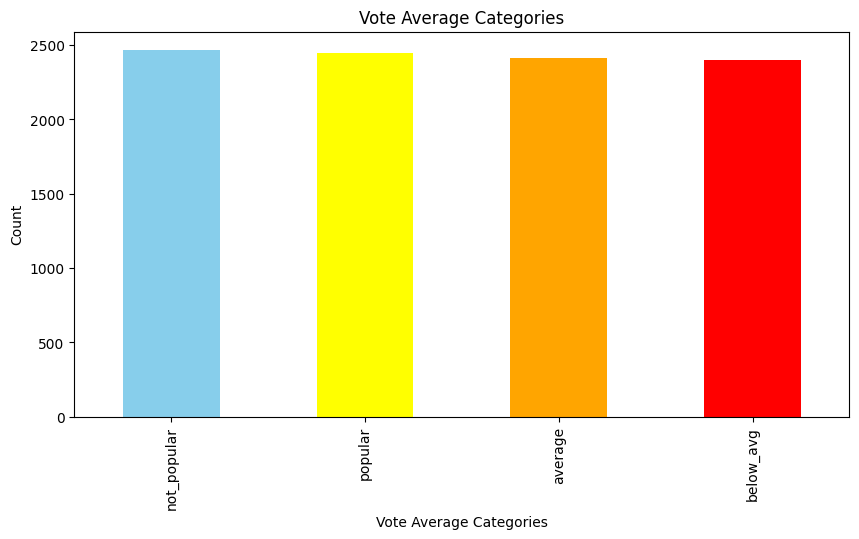

In [69]:
df['Vote_Average'].value_counts().plot(kind='bar', figsize=(10, 5), color=['skyblue','yellow','orange','red'])
plt.title('Vote Average Categories')
plt.xlabel('Vote Average Categories')
plt.ylabel('Count')


In [67]:
df.dropna(inplace=True)  # to drop rows with any NaN values
df.isna().sum()  # to check if there are any NaN values left in the dataset

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

## The `Genre` column contains extra spaces that should be stripped for consistent categorization.

In [70]:
df['Genre']= df['Genre'].str.split(', ')  # to split the 'Genre' column by ', '

df=df.explode('Genre').reset_index(drop=True)
df.head()                                      # to explode the 'Genre' column into multiple rows

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [71]:
## casting columns into categoary
df['Genre'] = df['Genre'].astype('category')  # to convert the 'Genre' column to category type
df['Genre'].dtypes  # to check the data type of the 'Genre' column


CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [72]:
df.info()  # to get the information about the dataset after all the changes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [73]:
df.nunique()  # to get the number of unique values in each column

Release_Date     100
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [74]:
df.head()  # Display the first few rows of the dataset after categorization

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


## DATA VISUALISATION OF THE DATA 

In [75]:
sns.set(style="whitegrid")  # Set the style for seaborn plots


## 1.	What is the most frequent genre of movies released on Netflix?

In [76]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

C:\Users\tusha\AppData\Local\Temp\ipykernel_18240\2695114854.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


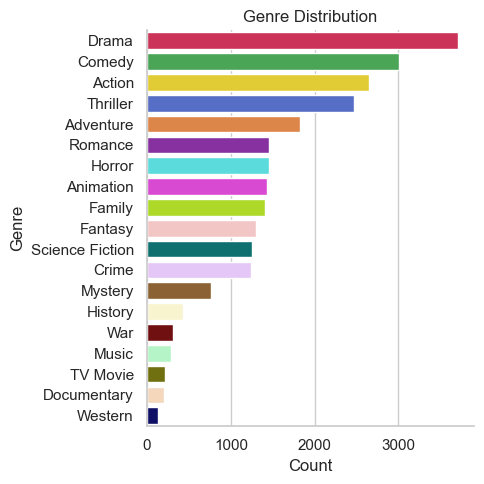

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Custom color palette
palette = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
    '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
    '#aaffc3', '#808000', '#ffd8b1', '#000075'
]


# Catplot with custom colors
sns.catplot(
    y='Genre',
    data=df,
    kind='count',
    order=df['Genre'].value_counts().index,
    palette=palette
)

plt.title('Genre Distribution')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


## 2.	Which genre has the highest number of votes?

C:\Users\tusha\AppData\Local\Temp\ipykernel_18240\2576647430.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Vote_Average', data=df, order=df['Vote_Average'].value_counts().index, palette='viridis')


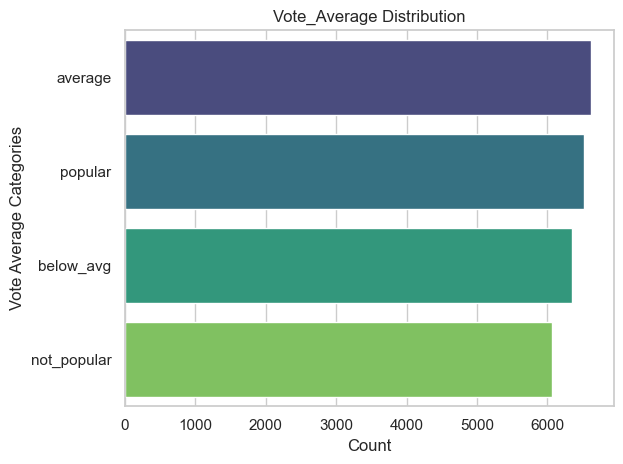

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
# Set the style for seaborn plots
sns.set(style="whitegrid")
# Create a count plot for the 'Genre' column
sns.countplot(y='Vote_Average', data=df, order=df['Vote_Average'].value_counts().index, palette='viridis')

plt.title('Vote_Average Distribution')
plt.xlabel('Count')
plt.ylabel('Vote Average Categories')
plt.tight_layout()
plt.show()

## 3.	What movie has the highest popularity? What’s its genre?

In [84]:
df.head(2)  # Display the first few rows of the dataset after categorization

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [85]:
df[df['Popularity']== df['Popularity'].max()]  # to get the title of the movie with the highest popularity

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


##	4.	What movie has the lowest popularity? What’s its genre?

In [86]:
df[df['Popularity']== df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
25551,1984,Threads,13.354,186,popular,Science Fiction


## 5.	Which year has the most movies filmed?

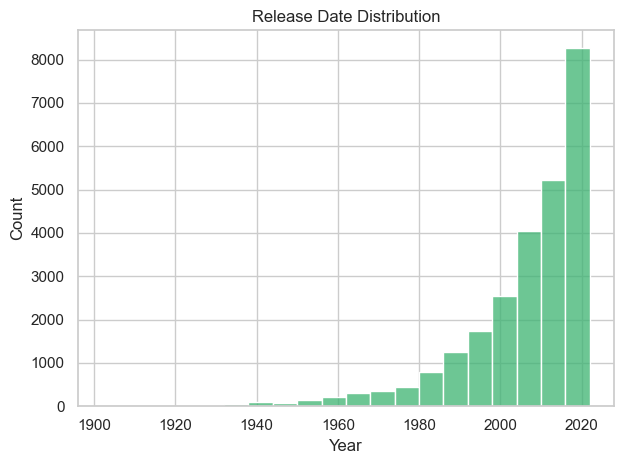

In [91]:
sns.histplot(data=df, x='Release_Date', bins=20, color='mediumseagreen')  # no palette for single series
plt.title('Release Date Distribution')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


  ## CONCLUSION AND RECOMMENDATIONS



## 📌 1. Focus on the Drama Genre
🧠 Insight:
Drama is the most frequent genre and also receives the highest number of votes, making it the most popular genre overall.

✅ Recommendations:

Production Studios: Prioritize the creation or acquisition of drama-based content to meet wide audience demand.

Streaming Platforms: Feature drama movies prominently in banners, categories, and personalized suggestions.

Marketers: Use emotional, story-driven marketing strategies to attract viewers to drama films.

## 📌 2. Optimize for Popular Genres in High-Vote Segments
🧠 Insight:
Genres like Drama, Action, and Adventure dominate the vote counts in the dataset.

✅ Recommendations:

Content Curation Teams: Build curated playlists such as “Top Voted Dramas” or “Fan Favorite Action Films”.

Recommendation Systems: Leverage genre-vote correlations to enhance user personalization models.

## 📌 3. Learn from Highly Popular Movies
🧠 Insight:
Spider-Man: No Way Home is the most popular movie, spanning the Action, Adventure, and Sci-Fi genres.

✅ Recommendations:

Studios/Producers: Invest in franchise-based, high-CGI, or superhero films with proven audience appeal.

Analysts: Examine the metadata (e.g., budget, cast, release timing) of top-performing films to understand success patterns.

## 📌 4. Investigate Low-Popularity Titles
🧠 Insight:
The United States vs. Billie Holiday is the least popular movie, despite having multiple genres (Music, Drama, War, Sci-Fi).

✅ Recommendations:

Analysts/Producers: Investigate potential reasons for poor performance — niche targeting, insufficient marketing, or release strategy.

Content Teams: Avoid mixing too many unrelated genres, which may lead to a lack of clear narrative focus.

## 📌 5. Capitalize on Peak Production Years
🧠 Insight:
The year 2020 saw the highest number of movie productions in the dataset.

✅ Recommendations:

Trend Analysts: Explore if the spike was due to external factors like streaming demand or pandemic-driven content shifts.

Catalog Managers: Apply quality filters to 2020 releases, as high volume may not equate to high quality